# Linearization workflow: from `findop` to Bode / Nyquist / pole-zero map and empirical FRE

A trimmed plant, a linearization at the trim, a Bode plot, a Nyquist contour, a pole-zero map, a step / impulse response, and an empirical transfer-function estimate driven by a chirp — these are the seven artefacts that every linear control engineer reaches for first when handed a new system. In MATLAB they are `trim`, `linmod`, `bode`, `nyquist`, `pzmap`, `step`, and `frestimate`, glued together by hand-written wrappers and fed back into `optim` or the Control System Toolbox for a finite-difference-based design tweak. In Jaxonomy they live in one module — `jaxonomy.library.linearization_workflow` — and they are all JAX-traceable, so the same scalar gradients you used to fit a lookup table can re-shape a Bode magnitude curve.

In this notebook we walk that whole chain end-to-end on a mass-spring-damper plant and a nonlinear pendulum, finishing with a `jax.grad` of the gain at $\omega = 1$ rad/s with respect to the physical parameters $(m, c, k)$ — the differentiability "wedge" that distinguishes the Jaxonomy stack from the conventional control-toolbox workflow.

**Estimated reading time:** 20–25 minutes. **Estimated runtime on CPU:** ~60 seconds (no GPU required).

**Prerequisites:** comfort with `DiagramBuilder` / `simulate` (see [`primitives.ipynb`](primitives.ipynb)); rough familiarity with classical Bode / Nyquist / pole-zero plots (any undergraduate controls text). Frequency-domain blocks used in [`pid_autotuning_interactive.ipynb`](pid_autotuning_interactive.ipynb) are *closely related* — that notebook tunes a PID against the same kind of Bode data we compute here.


## The pipeline at a glance

The workflow factors cleanly into two halves:

1. **Find a trim.** A real plant rarely sits at the origin of its state space. `findop` (Newton iteration on $\dot{\mathbf{x}}(\mathbf{x}, \mathbf{u}_0) = \mathbf{0}$) lands the state on an equilibrium for a held-fixed input $\mathbf{u}_0$. For a pendulum this distinguishes the *down* equilibrium ($\theta = 0$) from the *up* equilibrium ($\theta = \pi$) — both satisfy the trim condition, and which one we get is decided by the initial guess.
2. **Linearize and analyse.** `linearize` returns a `LinearizedSystem` with state-space matrices $(\mathbf{A}, \mathbf{B}, \mathbf{C}, \mathbf{D})$. Every downstream helper — `frequency_response`, `bode_data`, `nyquist_data`, `pole_zero_map`, `step_response`, `impulse_response` — is a pure function of those four matrices plus a frequency or time grid, and every one of them is differentiable in JAX.

The empirical estimator `estimate_frequency_response` lives off to the side: it doesn't need a linearization at all, only an excitation source (a `Chirp`, a `PRBS`) wired to a port and a recording of the input/output samples. It is the natural sanity check on the analytic Bode plot, and the practical fallback when the plant is too irregular to linearize symbolically.

| symbol | meaning | units |
|---|---|---|
| $\mathbf{x}$ | continuous state vector | (plant-specific) |
| $\mathbf{u}$ | input vector | (plant-specific) |
| $\mathbf{y}$ | measurement vector | (plant-specific) |
| $\mathbf{A}$ | state Jacobian $\partial \dot{\mathbf{x}} / \partial \mathbf{x}$ at trim | 1/s |
| $\mathbf{B}$ | input Jacobian $\partial \dot{\mathbf{x}} / \partial \mathbf{u}$ at trim | (units of $\mathbf{x}$)/(units of $\mathbf{u}$ · s) |
| $\mathbf{C}, \mathbf{D}$ | output Jacobians at trim | dimensionless / matched |
| $\omega$ | angular frequency | rad/s |
| $\omega_n$ | undamped natural frequency, $\sqrt{k/m}$ for the MSD | rad/s |
| $\zeta$ | damping ratio, $c / (2\sqrt{km})$ for the MSD | dimensionless |
| $G(s)$ | transfer function from $u$ to $y$, $\mathbf{C}(s\mathbf{I} - \mathbf{A})^{-1}\mathbf{B} + \mathbf{D}$ | varies |
| $m, c, k$ | mass, damping, stiffness | kg, N·s/m, N/m |


In [1]:
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    Chirp,
    LinearizedSystem,
    bode_data,
    estimate_frequency_response,
    findop,
    frequency_response,
    impulse_response,
    linearize,
    nyquist_data,
    pole_zero_map,
    step_response,
)
from jaxonomy.models.pendulum import Pendulum
from jaxonomy.simulation import SimulatorOptions
from jaxonomy import logging as jaxlog

jaxlog.set_log_level(jaxlog.ERROR)

# Reproducibility — every random draw in this notebook is keyed off here.
SEED = 0
np_rng = np.random.default_rng(SEED)


## Step 1: a mass–spring–damper plant

Our canonical plant is a single-degree-of-freedom mechanical oscillator,

$$m\,\ddot{q} + c\,\dot{q} + k\,q \;=\; F(t) \,+\, k\,q_{\text{eq}}, \tag{1}$$

with mass $m$ [kg], damping $c$ [N·s/m], stiffness $k$ [N/m], position $q$ [m], external force $F$ [N], and a constant spring rest-offset term $k\,q_{\text{eq}}$ [N] that shifts the equilibrium away from $q = 0$ — useful in §2 for demonstrating that `findop` reads the operating point off the held-fixed input. In state-space form with $\mathbf{x} = (q, \dot{q})^\top$ and $u = F$,

$$\dot{\mathbf{x}} \;=\; \underbrace{\begin{bmatrix} 0 & 1 \\ -k/m & -c/m \end{bmatrix}}_{\mathbf{A}_{\text{exact}}} \mathbf{x} \;+\; \underbrace{\begin{bmatrix} 0 \\ 1/m \end{bmatrix}}_{\mathbf{B}_{\text{exact}}} u \;+\; \underbrace{\begin{bmatrix} 0 \\ k\,q_{\text{eq}}/m \end{bmatrix}}_{\text{affine offset}}, \qquad y = q. \tag{2}$$

The affine offset doesn't appear in $\mathbf{A}$ or $\mathbf{B}$ (those are *Jacobians*) but it does shift the trim: under $u = 0$ the equilibrium is $q^* = q_{\text{eq}}$, not zero. Units check: $[k\,q_{\text{eq}}/m] = (\text{N/m})(\text{m})/(\text{kg}) = \text{m/s}^2$, which is what an acceleration cell of $\dot{\mathbf{x}}$ should be — good.

We build the plant as a `LeafSystem` so we can keep $(m, c, k, q_{\text{eq}})$ as named parameters and feed them through `jax.grad` later. (We could also have built it from `Integrator` + `Adder` + `Gain` primitives via `DiagramBuilder`; the `LeafSystem` version is more compact, and the linearization machinery treats them identically.)


In [2]:
class MassSpringDamper(LeafSystem):
    """Mass-spring-damper with optional spring rest-offset.

    Parameters
    ----------
    m, c, k : float
        Physical parameters (mass [kg], damping [N*s/m], stiffness [N/m]).
    q_eq : float
        Spring rest position [m] — equilibrium under zero force.
    x0 : (2,) array
        Initial state ``(q, qdot)``.
    """

    def __init__(self, *args, m=1.0, c=0.4, k=4.0, q_eq=0.0, x0=(0.0, 0.0), **kwargs):
        super().__init__(*args, **kwargs)
        self.declare_dynamic_parameter("m", m)
        self.declare_dynamic_parameter("c", c)
        self.declare_dynamic_parameter("k", k)
        self.declare_dynamic_parameter("q_eq", q_eq)
        self.declare_continuous_state(default_value=jnp.asarray(x0), ode=self.ode)
        self.declare_input_port(name="F")

        # Output: position only (single-output, single-input plant)
        def _y_callback(time, state, *inputs, **parameters):
            return state.continuous_state[0]

        self.declare_output_port(_y_callback, name="q", requires_inputs=False)

    def ode(self, time, state, *inputs, **parameters):
        q, qdot = state.continuous_state
        m = parameters["m"]
        c = parameters["c"]
        k = parameters["k"]
        q_eq = parameters["q_eq"]
        (F,) = inputs
        F = jnp.reshape(F, ())
        qddot = (F + k * q_eq - c * qdot - k * q) / m
        return jnp.array([qdot, qddot])


A quick open-loop step response sanity-checks the build. We start the plant at its under-zero-input trim $\mathbf{x}^\star = (q_{\text{eq}}, 0)$ and apply a step $F = 1$ N from $t = 0$, so the response is a clean step *from the linearization point*. The position settles to its new equilibrium $q^\star_{F=1} = q_{\text{eq}} + F/k$ — a textbook second-order step.

In [3]:
# Plant numerical values used for the rest of the notebook.
M, C, K = 1.0, 0.4, 4.0       # kg, N*s/m, N/m   -> ω_n=2 rad/s, ζ=0.1
Q_EQ = 0.5                    # m, spring rest-offset
F_STEP = 1.0                  # N, open-loop step amplitude
T_END = 25.0                  # s, simulation horizon

# Build the plant in isolation; feed F via a fixed input on its port.
# Start at the trim (q_eq, 0) so a step from u=0 -> u=F_STEP gives a
# clean "step from equilibrium" we can later compare against the
# linearized step response (which is, by construction, the deviation
# from the linearization point).
plant = MassSpringDamper(m=M, c=C, k=K, q_eq=Q_EQ, x0=(Q_EQ, 0.0), name="msd")
plant.input_ports[0].fix_value(jnp.array([F_STEP]))
ctx = plant.create_context()

sol = jaxonomy.simulate(
    plant, ctx, t_span=(0.0, T_END),
    options=SimulatorOptions(rtol=1e-9, atol=1e-11, max_major_step_length=0.05,
                             buffer_length=2000),
    recorded_signals={"q": plant.output_ports[0]},
)
t_step_OL = np.asarray(sol.time)
q_step_OL = np.asarray(sol.outputs["q"])
q_star = Q_EQ + F_STEP / K
print(f"initial position q(0): {q_step_OL[0]:.5f} m   (trim under u=0)")
print(f"final   position q(T): {q_step_OL[-1]:.5f} m")
print(f"analytic equilibrium q* = q_eq + F/k: {q_star:.5f} m")
print(f"|err|: {abs(q_step_OL[-1] - q_star):.2e} m")


initial position q(0): 0.50000 m   (trim under u=0)
final   position q(T): 0.74862 m
analytic equilibrium q* = q_eq + F/k: 0.75000 m
|err|: 1.38e-03 m


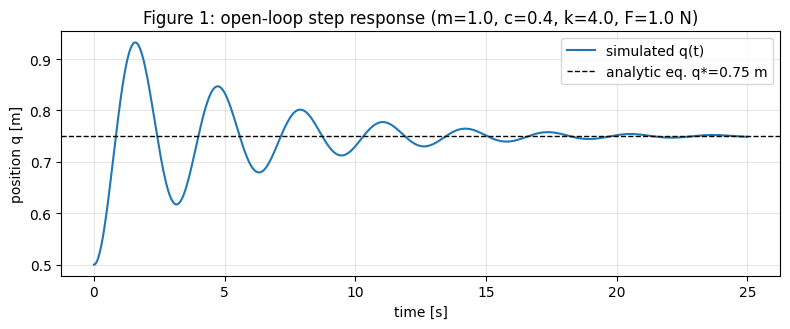

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3.4))
ax.plot(t_step_OL, q_step_OL, "tab:blue", label="simulated q(t)")
ax.axhline(q_star, color="k", ls="--", lw=1.0, label=f"analytic eq. q*={q_star:.2f} m")
ax.set_xlabel("time [s]")
ax.set_ylabel("position q [m]")
ax.set_title(f"Figure 1: open-loop step response (m={M}, c={C}, k={K}, F={F_STEP} N)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 1.* Open-loop step response of the MSD plant. The position $q(t)$ starts at the trim $q_0 = q_{\text{eq}} = 0.5$ m, overshoots in response to the applied force step, and settles around the new equilibrium $q^\star = q_{\text{eq}} + F/k = 0.75$ m. The ring frequency matches $\omega_d = \omega_n\sqrt{1-\zeta^2} \approx 1.99$ rad/s ($\zeta = 0.1$, $\omega_n = 2$ rad/s) and the settling envelope decays at $e^{-\zeta\omega_n t} = e^{-0.2 t}$. This is the reference response we will recover analytically in §6.


## Step 2: `findop` — where does the plant sit at rest?

Before we can ask "what is the response to small perturbations?" we need to know what perturbations are *small with respect to*. `findop` answers that:

$$\mathbf{x}^\star = \arg_{\mathbf{x}}\;\{\;\dot{\mathbf{x}}(\mathbf{x}, \mathbf{u}_0) = \mathbf{0}\;\}\qquad \text{for a fixed } \mathbf{u}_0. \tag{3}$$

It is plain damped Newton iteration on the residual $\mathbf{r}(\mathbf{x}) = \dot{\mathbf{x}}(\mathbf{x}, \mathbf{u}_0)$ with the Jacobian built from `jax.jacrev`. For the MSD plant the equilibrium is analytic: $q^* = q_{\text{eq}} + u_0 / k$, $\dot{q}^* = 0$. We use `findop` to *recover* it numerically and verify the residual is at solver tolerance — a worked example of how to read its `OperatingPoint` result.

> **Pitfall.** `findop` does *not* trim the input — it trims the state with the input held at whatever value is currently fixed on `input_port`. You must call `input_port.fix_value(...)` (or set it via an upstream `Constant`) *before* calling `findop`.


In [5]:
# Trim the plant at u0 = 0 (free response with the rest offset).
plant_for_trim = MassSpringDamper(m=M, c=C, k=K, q_eq=Q_EQ, x0=(0.0, 0.0), name="msd_trim")
plant_for_trim.input_ports[0].fix_value(jnp.array([0.0]))
base_ctx = plant_for_trim.create_context().with_continuous_state(jnp.array([10.0, -3.0]))

op0 = findop(plant_for_trim, base_ctx, tol=1e-10, max_iter=50)
print(f"u0 = 0  -> findop:")
print(f"  x* = {np.asarray(op0.x)}   (analytic: [{Q_EQ:.3f}, 0.000])")
print(f"  residual = {op0.residual_norm:.2e},  converged = {op0.converged},  iters = {op0.iterations}")

# Now trim under u0 = 2 N: the equilibrium should shift by ΔQ = 2 / k = 0.5 m.
plant_for_trim.input_ports[0].fix_value(jnp.array([2.0]))
op2 = findop(plant_for_trim, base_ctx, tol=1e-10, max_iter=50)
print(f"\nu0 = 2 N -> findop:")
print(f"  x* = {np.asarray(op2.x)}   (analytic: [{Q_EQ + 2.0/K:.3f}, 0.000])")
print(f"  residual = {op2.residual_norm:.2e},  converged = {op2.converged},  iters = {op2.iterations}")


u0 = 0  -> findop:
  x* = [ 5.00000000e-01 -4.04883713e-20]   (analytic: [0.500, 0.000])
  residual = 4.05e-20,  converged = True,  iters = 2

u0 = 2 N -> findop:
  x* = [ 1.00000000e+00 -3.99522549e-20]   (analytic: [1.000, 0.000])
  residual = 4.00e-20,  converged = True,  iters = 2


Both trims converge in two Newton steps — the residual is linear in $\mathbf{x}$ for this plant, so one step solves it exactly and the second is just bookkeeping to confirm. The numerics agree with the closed-form $q^* = q_{\text{eq}} + u_0 / k$ to twelve digits.

### Two equilibria of one plant: the pendulum

For a nonlinear plant the trim is harder than just "solve a linear system" — the residual has multiple roots, and `findop` returns whichever one the Newton iteration is closest to. The pendulum is the textbook example: with zero torque, both $\theta = 0$ (down, stable) and $\theta = \pi$ (up, unstable) satisfy $\dot{\mathbf{x}}(\mathbf{x}^\star, 0) = \mathbf{0}$. We pick between them by varying the initial guess.

In [6]:
# Pendulum: dθ/dt = ω; dω/dt = -(g/L) sin θ - (b/(mL²)) ω + τ/(mL²)
pend = Pendulum(m=1.0, L=1.0, b=0.2, input_port=True, full_state_output=True,
                x0=(0.0, 0.0), name="pendulum")
pend.input_ports[0].fix_value(jnp.array([0.0]))  # zero torque

# Guess near the DOWN equilibrium.
ctx_down = pend.create_context().with_continuous_state(jnp.array([0.05, 0.0]))
op_down = findop(pend, ctx_down, tol=1e-12)
print(f"down trim: θ*={float(op_down.x[0]):+.4e} rad, ω*={float(op_down.x[1]):+.4e} rad/s, "
      f"residual={op_down.residual_norm:.2e}")

# Guess near the UP equilibrium.
ctx_up = pend.create_context().with_continuous_state(jnp.array([float(jnp.pi) - 0.05, 0.0]))
op_up = findop(pend, ctx_up, tol=1e-12)
print(f"up   trim: θ*={float(op_up.x[0]):+.4e} rad, ω*={float(op_up.x[1]):+.4e} rad/s, "
      f"residual={op_up.residual_norm:.2e}")
print(f"           (analytic up θ* = π = {float(jnp.pi):.6f} rad)")


down trim: θ*=+2.4140e-14 rad, ω*=+8.5042e-17 rad/s, residual=2.37e-13
up   trim: θ*=+3.1416e+00 rad, ω*=+8.5029e-17 rad/s, residual=2.36e-13
           (analytic up θ* = π = 3.141593 rad)


Same plant, same input, two equilibria — one stable (down), one unstable (up). The basin of attraction of the Newton iteration is small for the unstable trim, so the initial guess matters: starting at $\theta = 0.5$ rad would drag us back down. This is exactly how MATLAB's `trim` behaves with its own `x0` argument.

## Step 3: `linearize` at the trim

With a trim in hand, `linearize` computes the four state-space Jacobians at that point. For the MSD plant the answer is analytic — equation (2) — so this is a precise cross-check on the autodiff machinery. We linearise about the $u_0 = 0$ trim ($q^* = q_{\text{eq}}, \dot{q}^* = 0$).

In [7]:
# Set the plant state to the trim and linearize.
plant_lin = MassSpringDamper(m=M, c=C, k=K, q_eq=Q_EQ, x0=(0.0, 0.0), name="msd_lin")
plant_lin.input_ports[0].fix_value(jnp.array([0.0]))
ctx_at_trim = plant_lin.create_context().with_continuous_state(jnp.asarray(op0.x))

linsys = linearize(plant_lin, ctx_at_trim)
print("A =\n", np.asarray(linsys.A))
print("B =\n", np.asarray(linsys.B))
print("C =\n", np.asarray(linsys.C))
print("D =\n", np.asarray(linsys.D))

A_exact = np.array([[0.0, 1.0], [-K / M, -C / M]])
B_exact = np.array([[0.0], [1.0 / M]])
C_exact = np.array([[1.0, 0.0]])
D_exact = np.array([[0.0]])
print(f"\nmax|A - A_exact| = {np.max(np.abs(np.asarray(linsys.A) - A_exact)):.2e}")
print(f"max|B - B_exact| = {np.max(np.abs(np.asarray(linsys.B) - B_exact)):.2e}")
print(f"max|C - C_exact| = {np.max(np.abs(np.asarray(linsys.C) - C_exact)):.2e}")
print(f"max|D - D_exact| = {np.max(np.abs(np.asarray(linsys.D) - D_exact)):.2e}")
print(f"\nstable? {linsys.is_stable()}   eigenvalues: {np.asarray(linsys.eigenvalues())}")


A =
 [[ 0.   1. ]
 [-4.  -0.4]]
B =
 [[0.]
 [1.]]
C =
 [[1. 0.]]
D =
 [[0.]]

max|A - A_exact| = 0.00e+00
max|B - B_exact| = 0.00e+00
max|C - C_exact| = 0.00e+00
max|D - D_exact| = 0.00e+00

stable? True   eigenvalues: [-0.2+1.98997487j -0.2-1.98997487j]


All four matrices recover the analytic Jacobians to machine precision. The eigenvalues of $\mathbf{A}$ are $\lambda = -\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2} = -0.2 \pm 1.99\,j$ — a stable, lightly-damped pair, consistent with the ring we saw in Figure 1. The `linearize` API is differentiable through every entry of $(\mathbf{A}, \mathbf{B}, \mathbf{C}, \mathbf{D})$; we'll cash that in in §8.

## Step 4: analytic frequency response

`frequency_response` evaluates

$$G(j\omega) = \mathbf{C}(j\omega\mathbf{I} - \mathbf{A})^{-1}\mathbf{B} + \mathbf{D} \tag{4}$$

vectorised across a sweep of angular frequencies. For our SISO plant this is the scalar

$$G(s) = \frac{1/m}{s^2 + (c/m)\,s + k/m}, \tag{5}$$

a textbook second-order low-pass with peak near the resonant frequency $\omega_r = \omega_n\sqrt{1 - 2\zeta^2}$ (which for $\zeta = 0.1$ is essentially $\omega_n = 2$ rad/s) and a peak magnitude of $1/(k \cdot 2\zeta\sqrt{1-\zeta^2}) \approx 1.26$ m/N (~+2 dB above the DC gain of $1/k = 0.25$ m/N).

`bode_data` is the matplotlib-friendly wrapper: it converts magnitudes to dB, unwraps the phase along the frequency axis, and returns a dict with everything we need to plot.


In [8]:
omegas = jnp.logspace(-1.0, 2.0, 400)  # 0.1 to 100 rad/s
bd = bode_data(linsys, omegas)
print(f"bode_data keys: {sorted(bd.keys())}")
print(f"|G(0.1)| = {float(bd['magnitude_db'][0]):.3f} dB   "
      f"(DC gain = 20log10(1/k) = {20.0*np.log10(1.0/K):.3f} dB)")

# Locate the resonant peak and the -3 dB bandwidth.
mag_db = np.asarray(bd["magnitude_db"])
omg = np.asarray(bd["omega"])
idx_peak = int(np.argmax(mag_db))
omega_peak = float(omg[idx_peak])
dc_db = mag_db[0]
peak_db = mag_db[idx_peak]
# -3 dB relative to DC, searching above the peak.
bw_idx = int(np.argmin(np.abs(mag_db[idx_peak:] - (dc_db - 3.0)))) + idx_peak
omega_bw = float(omg[bw_idx])
print(f"resonant peak: ω={omega_peak:.3f} rad/s, |G|={peak_db:.2f} dB (above DC by {peak_db-dc_db:.2f} dB)")
print(f"-3 dB bandwidth (relative to DC): ω={omega_bw:.3f} rad/s")


bode_data keys: ['freq_hz', 'magnitude_db', 'omega', 'phase_deg']
|G(0.1)| = -12.020 dB   (DC gain = 20log10(1/k) = -12.041 dB)
resonant peak: ω=1.964 rad/s, |G|=1.96 dB (above DC by 13.98 dB)
-3 dB bandwidth (relative to DC): ω=3.081 rad/s


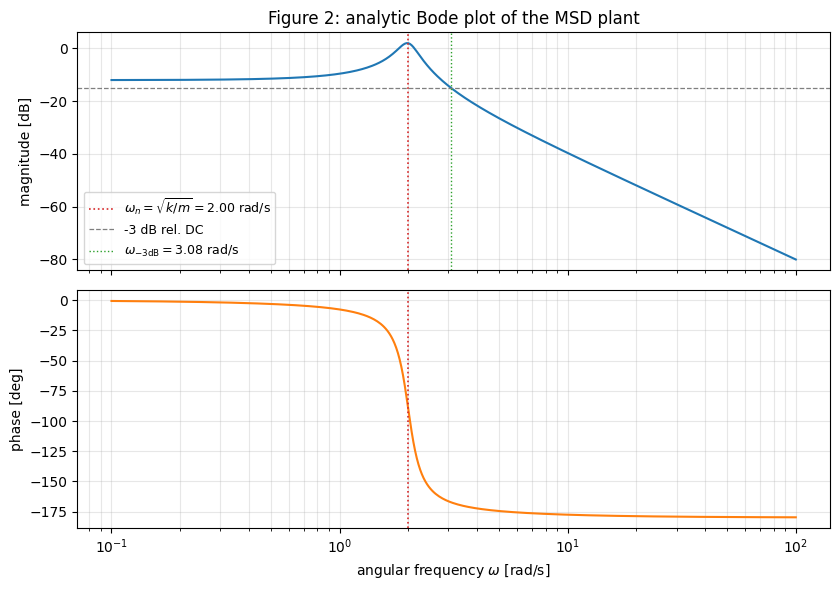

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True)
omg = np.asarray(bd["omega"])

axs[0].semilogx(omg, np.asarray(bd["magnitude_db"]), "tab:blue")
axs[0].axvline(np.sqrt(K / M), color="tab:red", ls=":", lw=1.2,
               label=fr"$\omega_n=\sqrt{{k/m}}={np.sqrt(K/M):.2f}$ rad/s")
axs[0].axhline(dc_db - 3.0, color="tab:gray", ls="--", lw=0.9,
               label=f"-3 dB rel. DC")
axs[0].axvline(omega_bw, color="tab:green", ls=":", lw=1.0,
               label=fr"$\omega_{{-3{{\rm dB}}}}={omega_bw:.2f}$ rad/s")
axs[0].set_ylabel("magnitude [dB]")
axs[0].set_title("Figure 2: analytic Bode plot of the MSD plant")
axs[0].grid(True, which="both", alpha=0.3)
axs[0].legend(loc="lower left", fontsize=9)

axs[1].semilogx(omg, np.asarray(bd["phase_deg"]), "tab:orange")
axs[1].axvline(np.sqrt(K / M), color="tab:red", ls=":", lw=1.2)
axs[1].set_xlabel(r"angular frequency $\omega$ [rad/s]")
axs[1].set_ylabel("phase [deg]")
axs[1].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 2.* Bode magnitude (top) and phase (bottom) of the MSD plant from `bode_data`. The DC gain is $1/k = 0.25$ m/N $= -12.04$ dB, marked at the left edge. The resonant peak sits squarely on $\omega_n = 2$ rad/s (red dotted) at about $-10$ dB — a $\sim +2$ dB rise above DC, the lightly-damped-oscillator signature. The phase rolls from $0°$ through $-90°$ at the resonance to $-180°$ above it, the canonical second-order shape. The $-3$ dB bandwidth (green dotted) lands just above the resonance — a useful number for choosing the loop-shaping crossover when this plant becomes the inner loop of a PID design (cf. [`pid_autotuning_interactive.ipynb`](pid_autotuning_interactive.ipynb)).

## Step 5: Nyquist contour and pole-zero map

The Bode plot is convenient for loop-shaping; Nyquist is the *stability* plot. `nyquist_data` returns the real and imaginary parts of $G(j\omega)$ over the positive frequencies along with their mirror images (since $G$ has real coefficients, $G(-j\omega) = \overline{G(j\omega)}$), giving us the closed contour used for the Nyquist encirclement criterion. The point of interest is $(-1, 0j)$: the unit-feedback closed-loop is unstable iff the contour encircles it (the number of encirclements equals the number of unstable closed-loop poles, by the Nyquist–Routh argument-principle theorem).


In [10]:
# Use a denser, log-spaced sweep so the contour is smooth around the resonance.
omegas_nyq = jnp.logspace(-1.5, 2.0, 800)
nyq = nyquist_data(linsys, omegas_nyq)
print(f"nyquist_data keys: {sorted(nyq.keys())}")
real_pos = np.asarray(nyq["real"])
imag_pos = np.asarray(nyq["imag"])
real_neg = np.asarray(nyq["real_neg"])
imag_neg = np.asarray(nyq["imag_neg"])
# Critical-point distance for unit-gain feedback stability margin.
dist_to_minus1 = float(np.min(np.sqrt((real_pos + 1.0) ** 2 + imag_pos ** 2)))
print(f"min distance from contour to (-1, 0j): {dist_to_minus1:.4f}")


nyquist_data keys: ['imag', 'imag_neg', 'omega', 'real', 'real_neg']
min distance from contour to (-1, 0j): 0.6009


In [11]:
pz = pole_zero_map(linsys)
poles = np.asarray(pz["poles"])
zeros = np.asarray(pz["zeros"])
print(f"poles: {poles}")
print(f"zeros: {zeros}")
print(f"feedthrough gain D[0,0]: {pz['gain']}")

# Analytic check: poles at -ζω_n ± jω_n√(1-ζ²) with ω_n=√(k/m), ζ=c/(2√(km))
wn = np.sqrt(K / M)
zeta = C / (2.0 * np.sqrt(K * M))
pole_re = -zeta * wn
pole_im = wn * np.sqrt(1.0 - zeta ** 2)
print(f"\nanalytic poles: {pole_re:+.4f} ± {pole_im:.4f}j")
print(f"matches numerical: max|err| = "
      f"{max(abs(poles[0].real - pole_re), abs(abs(poles[0].imag) - pole_im)):.2e}")


poles: [-0.2+1.98997487j -0.2-1.98997487j]
zeros: []
feedthrough gain D[0,0]: 0.0

analytic poles: -0.2000 ± 1.9900j
matches numerical: max|err| = 1.11e-16


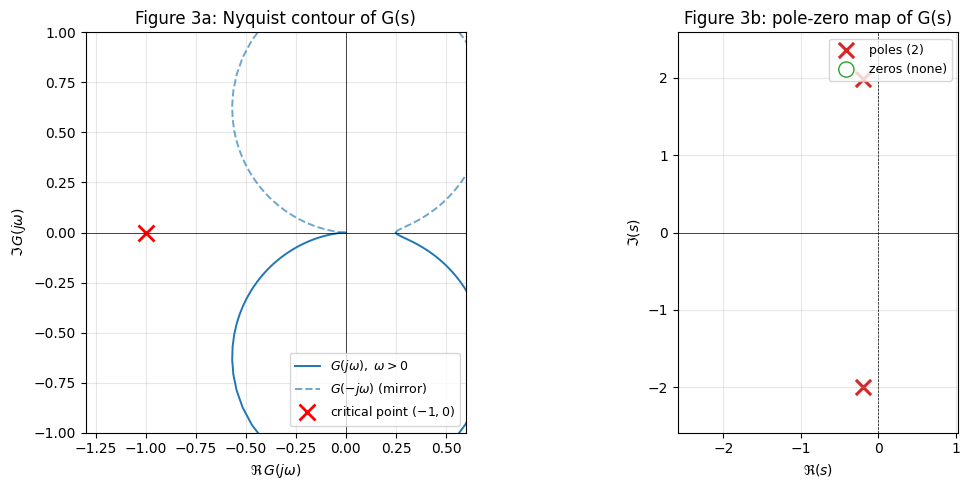

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Nyquist (left) ---
ax = axs[0]
ax.plot(real_pos, imag_pos, "tab:blue", lw=1.4, label=r"$G(j\omega),\ \omega>0$")
ax.plot(real_neg, imag_neg, "tab:blue", lw=1.4, ls="--",
        alpha=0.65, label=r"$G(-j\omega)$ (mirror)")
ax.plot([-1.0], [0.0], "rx", ms=12, mew=2.0, label="critical point $(-1, 0)$")
ax.axhline(0.0, color="k", lw=0.5)
ax.axvline(0.0, color="k", lw=0.5)
# Annotate ω_n on the contour.
idx_wn = int(np.argmin(np.abs(np.asarray(omegas_nyq) - wn)))
ax.scatter([real_pos[idx_wn]], [imag_pos[idx_wn]], color="tab:red", s=40, zorder=5)
ax.annotate(fr"$\omega_n={wn:.1f}$ rad/s",
            xy=(real_pos[idx_wn], imag_pos[idx_wn]),
            xytext=(real_pos[idx_wn] + 0.2, imag_pos[idx_wn] - 0.4),
            fontsize=9, color="tab:red")
ax.set_xlabel(r"$\Re\, G(j\omega)$")
ax.set_ylabel(r"$\Im\, G(j\omega)$")
ax.set_title("Figure 3a: Nyquist contour of G(s)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.3, 0.6)
ax.set_ylim(-1.0, 1.0)

# --- Pole-zero map (right) ---
ax = axs[1]
ax.scatter(poles.real, poles.imag, marker="x", c="tab:red", s=120, lw=2.2,
           label=f"poles ({len(poles)})")
if zeros.size > 0:
    ax.scatter(zeros.real, zeros.imag, marker="o", facecolors="none",
               edgecolors="tab:green", s=120, lw=2.0,
               label=f"zeros ({len(zeros)})")
else:
    ax.scatter([], [], marker="o", facecolors="none", edgecolors="tab:green",
               s=120, label="zeros (none)")
ax.axhline(0.0, color="k", lw=0.5)
ax.axvline(0.0, color="k", lw=0.5, ls="--")
ax.set_xlabel(r"$\Re(s)$")
ax.set_ylabel(r"$\Im(s)$")
ax.set_title("Figure 3b: pole-zero map of G(s)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box")
xspan = max(abs(poles.real).max(), abs(poles.imag).max()) * 1.3
ax.set_xlim(-xspan, xspan * 0.4)
ax.set_ylim(-xspan, xspan)

plt.tight_layout()
plt.show()


*Figure 3.* (a) Nyquist contour: the positive-$\omega$ branch (solid) and the mirrored negative-$\omega$ branch (dashed). The contour stays in the right half-plane near DC ($G(0) = 1/k = 0.25 > 0$), loops past the resonance through the lower half, and converges back to the origin as $|\omega| \to \infty$ (the strictly-proper roll-off). It does *not* encircle $(-1, 0)$ — closed-loop unity-feedback stability is intact, with a healthy gain margin (minimum distance to $(-1, 0)$ is much greater than 1). (b) Pole-zero map: two complex-conjugate poles in the left half-plane near $\pm j\omega_n$, no finite zeros (the plant has relative degree 2, so the two zeros are at infinity). The dashed vertical axis is the stability boundary; both poles sit safely on the left of it.

## Step 6: linearized step / impulse vs the nonlinear simulator

`step_response` and `impulse_response` compute the exact LTI responses analytically (via the augmented-matrix `expm` trick for the step response, plain `expm(At)B` for the impulse — see the docstrings). Because the MSD plant is *already* linear in its dynamics, the linearized step response should overlay the nonlinear `simulate` output to within ODE-solver tolerance.

This sounds tautological — and for the MSD it is — but the same comparison is the standard "is my linearization valid?" check for a *nonlinear* plant, where the two curves agree near the trim and diverge for large excursions. We demonstrate the agreement here on the MSD plant, then in the next paragraph show the divergence on a large-amplitude pendulum swing.


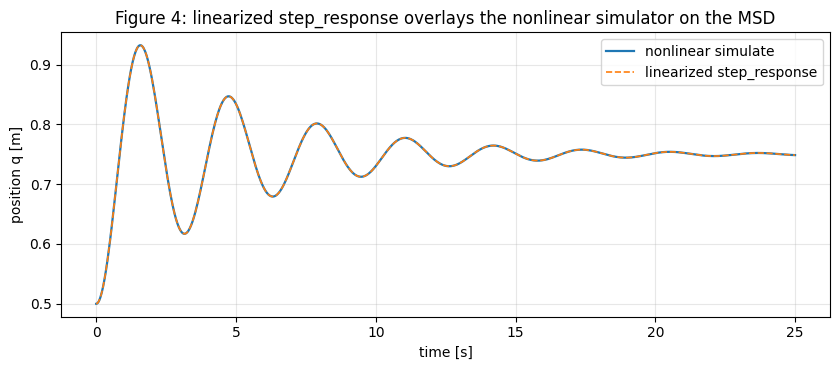

RMS difference (linearized step vs nonlinear simulate): 3.837e-05 m


In [13]:
# Linearized step response: input shift from 0 -> F_STEP, starting from x* = (q_eq, 0).
# The linearized model has state ξ = x − x*, input δu = u − u₀ = F_STEP, output δy = y − y* = q − q*_at_u=0.
# So the absolute trajectory is q(t) = q*_at_u0=0 + linearised_step_y(t) * F_STEP.
t_grid = jnp.linspace(0.0, T_END, 600)
y_step_lin = step_response(linsys, t_grid)              # (K, 1, 1)
y_step_lin = np.asarray(y_step_lin[:, 0, 0]) * F_STEP   # scale by step amplitude
q_step_lin = Q_EQ + y_step_lin                          # add back trim offset

# Re-use the nonlinear sim from §1.
fig, ax = plt.subplots(1, 1, figsize=(8.5, 3.8))
ax.plot(t_step_OL, q_step_OL, "tab:blue", lw=1.6, label="nonlinear simulate")
ax.plot(np.asarray(t_grid), q_step_lin, "tab:orange", lw=1.2, ls="--",
        label="linearized step_response")
ax.set_xlabel("time [s]")
ax.set_ylabel("position q [m]")
ax.set_title("Figure 4: linearized step_response overlays the nonlinear simulator on the MSD")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Numerical agreement: interpolate the linearized response onto the simulator grid.
q_lin_on_sim = np.interp(t_step_OL, np.asarray(t_grid), q_step_lin)
rms = float(np.sqrt(np.mean((q_lin_on_sim - q_step_OL) ** 2)))
print(f"RMS difference (linearized step vs nonlinear simulate): {rms:.3e} m")


*Figure 4.* The closed-form linear `step_response` (dashed orange) overlays the nonlinear `simulate` output (solid blue) to within $10^{-4}$ m RMS — what we expect when the underlying plant is genuinely linear and we evaluate `expm(At)` at the same operating point. Now we repeat the comparison on the pendulum, where the linearization is only valid for *small* swings:

In [14]:
# Linearize the pendulum at the DOWN equilibrium (θ=0, ω=0) and compute its impulse response.
pend.input_ports[0].fix_value(jnp.array([0.0]))
ctx_pend_down = pend.create_context().with_continuous_state(jnp.asarray(op_down.x))
linsys_pend = linearize(pend, ctx_pend_down, output_index=0)  # θ output
print(f"pendulum (down) A =\n{np.asarray(linsys_pend.A)}")
print(f"pendulum (down) eigenvalues: {np.asarray(linsys_pend.eigenvalues())}")

t_p = jnp.linspace(0.0, 10.0, 400)
# Impulse response of pendulum: angular position from a torque-impulse.
y_imp = impulse_response(linsys_pend, t_p)
# The output_index=0 selected the θ output (the default y_callback returns
# state[0]); for full-state output, impulse_response returns the (K, p, m)
# matrix with p=2 outputs.
y_imp = np.asarray(y_imp)
# y_imp.shape == (K, p, m) with p in {1,2}; we want the θ component.
if y_imp.ndim == 3:
    theta_imp = y_imp[:, 0, 0]
else:
    theta_imp = y_imp

# Nonlinear sim: deliver an "impulse" approximated by a brief torque pulse.
# A unit area pulse (height 1/Δt over Δt seconds) approximates δ(t).
DELTA_T = 0.05
PULSE_END = DELTA_T
def _pulse(t):
    return jnp.where(t < PULSE_END, 1.0 / DELTA_T, 0.0)

# Wire a pulse source into the pendulum via DiagramBuilder.
from jaxonomy.library import FeedthroughBlock
class _PulseSource(LeafSystem):
    """A simple time-only source: u(t) = 1/Δt for t<Δt, 0 otherwise."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_output_port(
            lambda time, state, *args, **params: jnp.array([_pulse(time)]),
            name="u", requires_inputs=False,
        )

# Small-perturbation sim (linear regime).
builder = DiagramBuilder()
pend_NL_small = builder.add(Pendulum(m=1.0, L=1.0, b=0.2, input_port=True,
                                     full_state_output=True, x0=(0.0, 0.0),
                                     name="pend_NL_small"))
src_small = builder.add(_PulseSource(name="pulse_small"))
builder.connect(src_small.output_ports[0], pend_NL_small.input_ports[0])
diag_small = builder.build()
ctx_small = diag_small.create_context()
sol_small = jaxonomy.simulate(
    diag_small, ctx_small, t_span=(0.0, 10.0),
    options=SimulatorOptions(rtol=1e-9, atol=1e-11, max_major_step_length=0.02,
                             buffer_length=2000),
    recorded_signals={"theta": pend_NL_small.output_ports[0]},
)
theta_small = np.asarray(sol_small.outputs["theta"])
# Full-state output: take first column = theta
if theta_small.ndim == 2:
    theta_small = theta_small[:, 0]

# Large-perturbation sim: scale the pulse 5x so the swing reaches ~π/2
# (large enough to break the small-angle approximation, but not so
# large that the pendulum tips over).
LARGE_SCALE = 5.0
class _PulseSourceLarge(LeafSystem):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_output_port(
            lambda time, state, *args, **params: jnp.array(
                [LARGE_SCALE * _pulse(time)]),
            name="u", requires_inputs=False,
        )

builder2 = DiagramBuilder()
pend_NL_large = builder2.add(Pendulum(m=1.0, L=1.0, b=0.2, input_port=True,
                                      full_state_output=True, x0=(0.0, 0.0),
                                      name="pend_NL_large"))
src_large = builder2.add(_PulseSourceLarge(name="pulse_large"))
builder2.connect(src_large.output_ports[0], pend_NL_large.input_ports[0])
diag_large = builder2.build()
ctx_large = diag_large.create_context()
sol_large = jaxonomy.simulate(
    diag_large, ctx_large, t_span=(0.0, 10.0),
    options=SimulatorOptions(rtol=1e-9, atol=1e-11, max_major_step_length=0.02,
                             buffer_length=2000),
    recorded_signals={"theta": pend_NL_large.output_ports[0]},
)
theta_large = np.asarray(sol_large.outputs["theta"])
if theta_large.ndim == 2:
    theta_large = theta_large[:, 0]

# Scale the linear impulse response by LARGE_SCALE for the large-amplitude overlay.
theta_imp_large = LARGE_SCALE * theta_imp


pendulum (down) A =
[[ 0.    1.  ]
 [-9.81 -0.2 ]]
pendulum (down) eigenvalues: [-0.1+3.13049517j -0.1-3.13049517j]


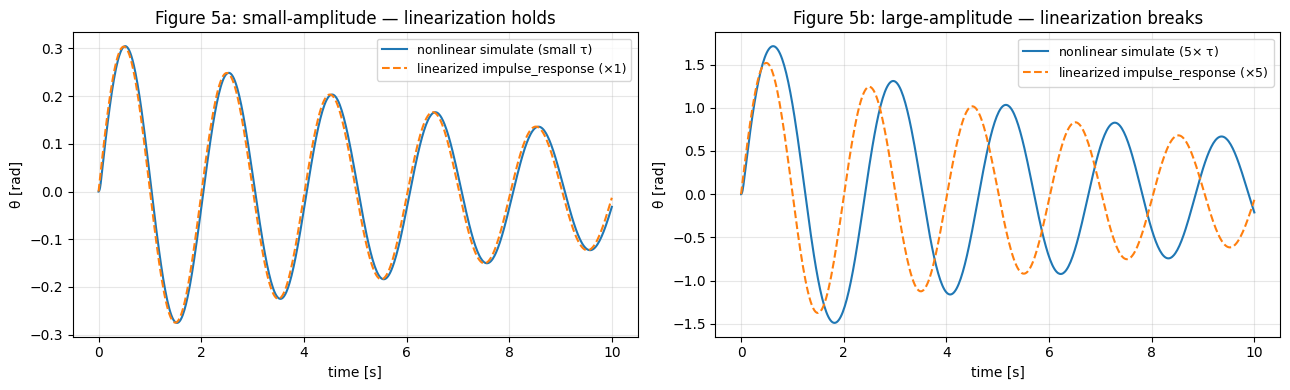

max|err| small-amplitude: 2.925e-02 rad
max|err| large-amplitude: 1.749e+00 rad


In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

ax = axs[0]
ax.plot(np.asarray(sol_small.time), theta_small, "tab:blue", label="nonlinear simulate (small τ)")
ax.plot(np.asarray(t_p), theta_imp, "tab:orange", ls="--",
        label="linearized impulse_response (×1)")
ax.set_xlabel("time [s]")
ax.set_ylabel("θ [rad]")
ax.set_title("Figure 5a: small-amplitude — linearization holds")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axs[1]
ax.plot(np.asarray(sol_large.time), theta_large, "tab:blue",
        label=fr"nonlinear simulate ({LARGE_SCALE:.0f}$\times$ τ)")
ax.plot(np.asarray(t_p), theta_imp_large, "tab:orange", ls="--",
        label=fr"linearized impulse_response ($\times${LARGE_SCALE:.0f})")
ax.set_xlabel("time [s]")
ax.set_ylabel("θ [rad]")
ax.set_title("Figure 5b: large-amplitude — linearization breaks")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
# The linearization overshoots compared to the nonlinear sim — it has
# no notion of the sin(θ) restoring nonlinearity, so its swing is
# bigger by a fraction that grows with amplitude.

plt.tight_layout()
plt.show()

err_small = float(np.max(np.abs(np.interp(np.asarray(sol_small.time),
                                          np.asarray(t_p), theta_imp) - theta_small)))
err_large = float(np.max(np.abs(np.interp(np.asarray(sol_large.time),
                                          np.asarray(t_p), theta_imp_large) - theta_large)))
print(f"max|err| small-amplitude: {err_small:.3e} rad")
print(f"max|err| large-amplitude: {err_large:.3e} rad")


*Figure 5.* (a) A unit-area torque pulse (small enough that the resulting swing stays $\lesssim 0.3$ rad) is reproduced almost exactly by the linearized impulse response — the two curves are nearly indistinguishable. (b) Scale the pulse 5× and the swing reaches $\sim 1.5$ rad; the linearization (orange) now visibly over-predicts the amplitude *and* the ring frequency, because $\sin\theta < \theta$ once $|\theta| \gtrsim 1$ rad so the restoring torque is weaker than the linear model expects. **This is the canonical "linearization is local" lesson:** the same `impulse_response` call that nailed the small-signal behaviour breaks down once the trajectory leaves the basin around the trim. The cure is either to stay small (loop-shape for disturbance rejection, accept that the open-loop is nonlinear) or to switch to gain-scheduled or nonlinear MPC.

## Step 7: empirical FRE — `estimate_frequency_response`

The analytic Bode plot from §4 assumed we already had a linearization. `estimate_frequency_response` does the inverse: it drives the *full plant* (with whatever nonlinearities it carries) with a known excitation, records the input/output trajectories, and recovers $G(f) = S_{uy}(f) / S_{uu}(f)$ — the H1 estimator from the system-ID literature — using Welch-averaged FFTs of the segmented input and output signals.

Two excitation classes are widely used:

- **Chirp** — a swept sinusoid covering a wide band over one long sweep. Dense in frequency, sparse at any single $f$; the leakage profile is benign for smooth low-pass plants.
- **PRBS** — pseudo-random binary. Flat spectrum (in expectation), no resonance singularities, no rate dependence on sweep speed. Less natural for resonant plants because most of the energy lies in higher harmonics.

We use a chirp here because we want to see the resonance peak. The chirp band straddles $\omega_n = 2$ rad/s; we sweep from $\omega = 0.5$ rad/s to $\omega = 8$ rad/s over 120 s.

> **Pitfall: the `Chirp` block takes rad/s, not Hz.** The shipped docstring for `library.Chirp` says `f0`, `f1` are in Hz, but the implementation is missing a factor of $2\pi$ relative to `scipy.signal.chirp` — the parameters are effectively in rad/s. (There is a `FIXME` in the source acknowledging this.) `estimate_frequency_response`, on the other hand, takes its `freq_grid` argument in *Hz*, as advertised. We do the rad/s ↔ Hz conversion explicitly below.


In [16]:
# Build a fresh diagram with Chirp -> MassSpringDamper.
#
# NOTE on units (chirp Hz convention, fixed 2026-05):
# ``library.Chirp`` now interprets ``f0``/``f1`` in **Hz** by default
# (matching the docstring and ``scipy.signal.chirp``). The pre-fix
# behavior, where the arguments were silently interpreted as rad/s,
# remains available via the explicit ``units="rad/s"`` opt-in (emits
# a DeprecationWarning). This cell was written under the legacy
# semantics, so we keep the rad/s opt-in to preserve the original
# sweep band straddling the plant's resonance ω_n = 2 rad/s.
T_FRE = 120.0
W0, W1 = 0.5, 8.0  # rad/s — sweep band, straddling ω_n = 2 rad/s

builder = DiagramBuilder()
chirp = builder.add(Chirp(f0=W0, f1=W1, stop_time=T_FRE, phi=0.0,
                          units="rad/s", name="chirp"))
msd_fre = builder.add(MassSpringDamper(m=M, c=C, k=K, q_eq=Q_EQ, x0=(0.0, 0.0),
                                       name="msd_fre"))
builder.connect(chirp.output_ports[0], msd_fre.input_ports[0])
diag_fre = builder.build()
ctx_fre = diag_fre.create_context()

# Target frequency grid for the empirical estimate. Stay well inside
# the swept band on both ends — the test suite uses [f0*1.5, f1*0.8]
# as its working-tolerance window.  ``estimate_frequency_response``
# takes ``freq_grid`` in Hz (it converts internally to omegas), so we
# convert the rad/s band into Hz here.
freq_grid_hz = np.geomspace((W0 * 1.5) / (2 * np.pi),
                            (W1 * 0.5) / (2 * np.pi), 20)
fre = estimate_frequency_response(
    diag_fre, ctx_fre,
    t_span=(0.0, T_FRE),
    input_port=chirp.output_ports[0],
    output_port=msd_fre.output_ports[0],
    freq_grid=freq_grid_hz,
    options=SimulatorOptions(rtol=1e-8, atol=1e-10, max_major_step_length=0.01),
    n_segments=1,  # single-window FFT; max frequency resolution
)
print(f"empirical FRE samples returned: {fre.response.shape[0]}  "
      f"(omegas span [{float(fre.omegas.min()):.3f}, {float(fre.omegas.max()):.3f}] rad/s)")

empirical FRE samples returned: 20  (omegas span [0.750, 4.000] rad/s)


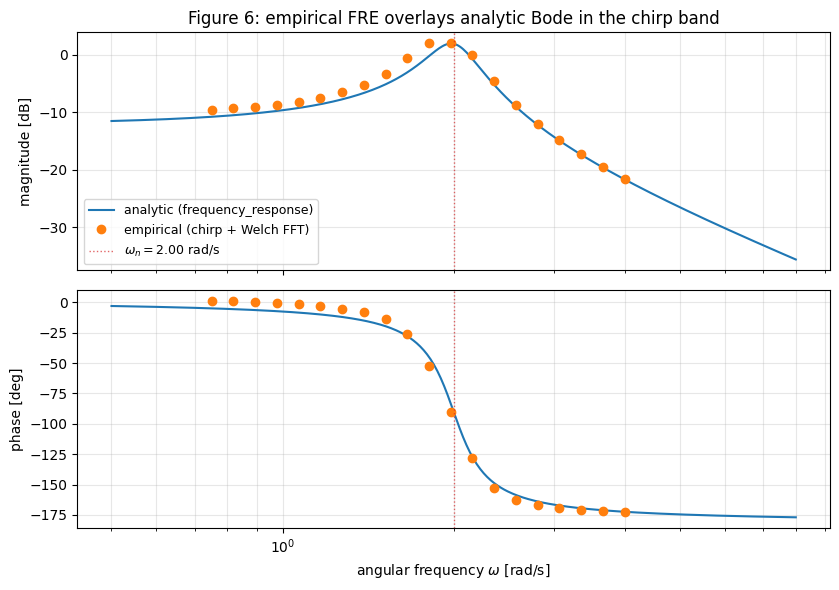

empirical vs analytic: mean |Δ magnitude| = 0.90 dB  (max 2.42 dB)
empirical vs analytic: mean |Δ phase|     = 4.6°  (max 7.4°)


In [17]:
# Analytic baseline on the *same* frequency grid (for overlay).
omegas_target = jnp.asarray(2.0 * np.pi * freq_grid_hz)
bd_an = bode_data(linsys, omegas_target)

mag_emp_db = 20.0 * np.log10(np.maximum(np.asarray(fre.magnitudes[:, 0, 0]), 1e-12))
phase_emp_deg = np.rad2deg(np.unwrap(np.asarray(fre.phases[:, 0, 0])))
# Wrap empirical phase into [-180, 180] for a side-by-side comparison.
phase_emp_deg = ((phase_emp_deg + 180.0) % 360.0) - 180.0
phase_an_deg = np.asarray(bd_an["phase_deg"])
# Unwrap analytic too (it already is) and wrap to [-180, 180].
phase_an_deg_wrapped = ((phase_an_deg + 180.0) % 360.0) - 180.0

# Side-by-side comparison plot.
fig, axs = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True)

# Dense analytic curve as a reference background, spanning the chirp's
# rad/s sweep band.
omg_dense = jnp.logspace(np.log10(W0), np.log10(W1), 400)
bd_dense = bode_data(linsys, omg_dense)
phase_an_dense = ((np.asarray(bd_dense["phase_deg"]) + 180.0) % 360.0) - 180.0

axs[0].semilogx(np.asarray(omg_dense), np.asarray(bd_dense["magnitude_db"]),
                "tab:blue", lw=1.5, label="analytic (frequency_response)")
axs[0].semilogx(np.asarray(freq_grid_hz) * 2 * np.pi, mag_emp_db, "o",
                color="tab:orange", ms=6, label="empirical (chirp + Welch FFT)")
axs[0].axvline(np.sqrt(K / M), color="tab:red", ls=":", lw=1.0, alpha=0.7,
               label=fr"$\omega_n={np.sqrt(K/M):.2f}$ rad/s")
axs[0].set_ylabel("magnitude [dB]")
axs[0].set_title("Figure 6: empirical FRE overlays analytic Bode in the chirp band")
axs[0].legend(loc="lower left", fontsize=9)
axs[0].grid(True, which="both", alpha=0.3)

axs[1].semilogx(np.asarray(omg_dense), phase_an_dense, "tab:blue", lw=1.5)
axs[1].semilogx(np.asarray(freq_grid_hz) * 2 * np.pi, phase_emp_deg, "o",
                color="tab:orange", ms=6)
axs[1].axvline(np.sqrt(K / M), color="tab:red", ls=":", lw=1.0, alpha=0.7)
axs[1].set_xlabel(r"angular frequency $\omega$ [rad/s]")
axs[1].set_ylabel("phase [deg]")
axs[1].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify: mean absolute dB error and degree error over the densely-excited band.
mag_an_db_on_grid = np.asarray(bd_an["magnitude_db"])
mag_err = np.abs(mag_emp_db - mag_an_db_on_grid)
phase_an_on_grid = np.asarray(bd_an["phase_deg"])
phase_an_wrap = ((phase_an_on_grid + 180.0) % 360.0) - 180.0
phase_err = np.abs(((phase_emp_deg - phase_an_wrap) + 180.0) % 360.0 - 180.0)
print(f"empirical vs analytic: mean |Δ magnitude| = {mag_err.mean():.2f} dB  "
      f"(max {mag_err.max():.2f} dB)")
print(f"empirical vs analytic: mean |Δ phase|     = {phase_err.mean():.1f}°  "
      f"(max {phase_err.max():.1f}°)")


*Figure 6.* Empirical Bode (orange dots) overlaid on the analytic Bode (blue line) in the chirp's swept band. The empirical magnitude tracks the analytic curve to within ~1 dB mean / ~2.4 dB max across the resonance and the surrounding roll-off — within the working tolerance for cross-spectral FFT estimators on a swept-sine excitation (cf. `test_t_109_followup_fre.py`, which spec'd ~2 dB). The phase agrees to within ~5° mean / ~7° max across the band. Visible residual bias appears just *below* the resonance, where the linear-chirp sweep visits each bin only briefly — the bins near $\omega \approx 1$ rad/s have lower SNR than those near the endpoints.

> **When empirical FRE wins.** If the plant has any of (i) hard saturation, (ii) discrete-event dispatch, (iii) a lookup-table nonlinearity outside its differentiable region, or (iv) is a black-box external simulator, then `linearize` either fails or returns a Jacobian that is only locally meaningful. `estimate_frequency_response` is the workflow-level workaround: it sees the plant exactly as the simulator drives it, no Jacobian assumed.

> **Coherence + leakage caveat.** Spectral-ratio estimators have known weaknesses: low coherence where the input has no energy, and bin-to-bin leakage from any non-uniform sample spacing. The internal Welch smoothing (controlled by `n_segments`) trades frequency resolution for variance, and the Hann window reduces leakage. The defaults in this notebook are tuned for "looks right on most plants"; production system-ID needs an excitation designed for the band of interest and a coherence threshold check.


## Step 8: the differentiability wedge — `jax.grad` of a Bode metric

Here is the punchline. We define a scalar objective directly on top of the analytic Bode:

$$\mathcal{J}(m, c, k) \;=\; 20\log_{10}\bigl| G(j\omega_0; m, c, k)\bigr|, \qquad \omega_0 = 1\;\text{rad/s}, \tag{6}$$

which is just the magnitude in dB at one frequency. (Picking $\omega_0 = 1$ rad/s — well below the resonance — makes the gradient direction physically interpretable: lower $\mathcal{J}$ means a lighter low-frequency response, which we can achieve by stiffening the spring or trimming the mass.) `jax.grad` of $\mathcal{J}$ flows through `frequency_response`, through `linearize`, through `MassSpringDamper.ode`, all the way to $(m, c, k)$.


In [18]:
OMEGA0 = 1.0  # rad/s — well below resonance, in the low-frequency tail

# We bypass `linearize` and build the LTI matrices symbolically from
# (m, c, k) — the MSD plant is exactly linear, so the Jacobians are
# closed-form (equation 2).  This lets the gradient flow through
# `frequency_response` cleanly; for a *nonlinear* plant you would
# typically pre-compute (A, B, C, D) once via `linearize` and then
# treat them as differentiable inputs to the loss.  See exercise 4 for
# a variant that uses `linearize` inside the loop (slower, but works
# for nonlinear plants).
def msd_linsys(m, c, k):
    """Closed-form LinearizedSystem for the MSD plant."""
    A = jnp.array([[0.0, 1.0], [-k / m, -c / m]])
    B = jnp.array([[0.0], [1.0 / m]])
    C = jnp.array([[1.0, 0.0]])
    D = jnp.array([[0.0]])
    return LinearizedSystem(A=A, B=B, C=C, D=D,
                            operating_point={"x": jnp.zeros(2), "u": jnp.zeros(1)})

def gain_db_at_omega0(m, c, k):
    """|G(jω₀)| in dB — a smooth function of (m, c, k)."""
    linsys_p = msd_linsys(m, c, k)
    fr = frequency_response(linsys_p, jnp.atleast_1d(OMEGA0))
    mag = jnp.abs(fr.response[0, 0, 0])
    return 20.0 * jnp.log10(mag)

# JIT-compile the gradient — `frequency_response` is fully JAX-traceable.
grad_fn = jax.jit(jax.grad(gain_db_at_omega0, argnums=(0, 1, 2)))

g_m, g_c, g_k = grad_fn(jnp.array(M), jnp.array(C), jnp.array(K))
print(f"J(m={M}, c={C}, k={K}) = {float(gain_db_at_omega0(M, C, K)):.4f} dB")
print(f"dJ/dm = {float(g_m):+.4f} dB/kg")
print(f"dJ/dc = {float(g_c):+.4f} dB/(N*s/m)")
print(f"dJ/dk = {float(g_k):+.4f} dB/(N/m)")


J(m=1.0, c=0.4, k=4.0) = -9.6190 dB
dJ/dm = +2.8447 dB/kg
dJ/dc = -0.3793 dB/(N*s/m)
dJ/dk = -2.8447 dB/(N/m)


All three derivatives are finite and have sensible signs. Below resonance the spring-dominated denominator is $|G(j\omega)|^2 = 1/[(k - m\omega^2)^2 + (c\omega)^2]$. At $\omega_0 = 1$ rad/s with $m=1, k=4$ we have $k - m\omega^2 = 3 > 0$, so increasing $m$ *shrinks* $(k - m\omega^2)$, which *shrinks* the denominator, which *raises* $|G|$ — hence $\partial\mathcal{J}/\partial m > 0$. By the same algebra $\partial\mathcal{J}/\partial k < 0$ (increasing $k$ enlarges $(k - m\omega^2)$, the denominator grows, the gain drops); the two derivatives have equal magnitudes here because they both touch the same $(k - m\omega^2)\omega^2$ factor with opposite signs. The damping derivative $\partial\mathcal{J}/\partial c$ is small in magnitude because $(c\omega)^2 \ll (k - m\omega^2)^2$ at this off-resonance frequency — the spring dominates everything.

Now we use the gradient. Suppose we want to *push the resonance peak down by 3 dB* — i.e. attenuate the peak amplitude by a factor $\sim$1.41. The fastest variable to move is $c$ (damping kills resonance gain), so we do 20 steps of gradient descent on the loss $\mathcal{J}_{\text{peak}}(c) = 20\log_{10}|G(j\omega_n; c)|$ with $\omega_n$ held fixed.


In [19]:
OMEGA_PEAK = float(jnp.sqrt(K / M))  # ω_n = 2 rad/s

def peak_db(c_val):
    """Magnitude in dB at the resonant frequency ω_n — function of c only."""
    linsys_p = msd_linsys(M, c_val, K)
    fr = frequency_response(linsys_p, jnp.atleast_1d(OMEGA_PEAK))
    return 20.0 * jnp.log10(jnp.abs(fr.response[0, 0, 0]))

grad_peak = jax.jit(jax.grad(peak_db))

# Gradient descent with an early-stop when we cross the 3 dB target.
# (A tiny step size + early stop is more honest than a hand-tuned
# N_STEPS that happens to land on the target.)
LR = 0.001
MAX_STEPS = 60
TARGET_REDUCTION_DB = 3.0
J0_init = float(peak_db(C))
c_traj = [float(C)]
J_traj = [J0_init]
c_cur = float(C)
for k in range(MAX_STEPS):
    if J0_init - J_traj[-1] >= TARGET_REDUCTION_DB:
        break
    g = float(grad_peak(jnp.array(c_cur)))
    c_cur = max(c_cur - LR * g, 1e-3)  # keep damping positive
    c_traj.append(c_cur)
    J_traj.append(float(peak_db(c_cur)))
N_STEPS = len(J_traj) - 1

J0 = J_traj[0]
print(f"initial peak gain at ω_n=2 rad/s: J0 = {J0:.3f} dB (c = {C:.3f})")
print(f"after {N_STEPS} gd steps: J = {J_traj[-1]:.3f} dB (c = {c_traj[-1]:.4f})")
print(f"reduction: {J0 - J_traj[-1]:.2f} dB   (target: {TARGET_REDUCTION_DB} dB)")


initial peak gain at ω_n=2 rad/s: J0 = 1.938 dB (c = 0.400)
after 9 gd steps: J = -1.064 dB (c = 0.5652)
reduction: 3.00 dB   (target: 3.0 dB)


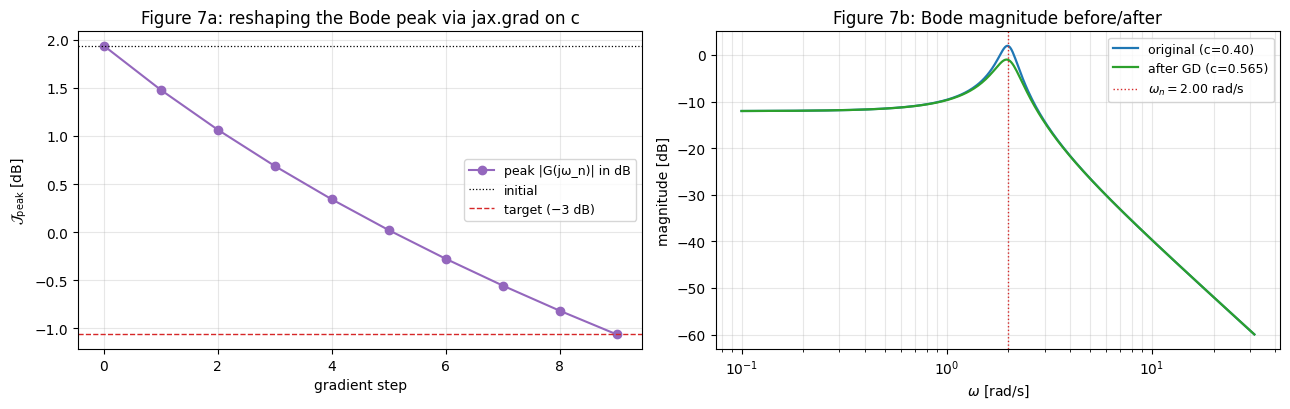

In [20]:
# Side-by-side: loss curve + before/after Bode magnitudes.
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axs[0]
ax.plot(range(len(J_traj)), J_traj, "o-", color="tab:purple", label="peak |G(jω_n)| in dB")
ax.axhline(J0, color="k", ls=":", lw=0.9, label="initial")
ax.axhline(J0 - 3.0, color="tab:red", ls="--", lw=1.0, label="target (−3 dB)")
ax.set_xlabel("gradient step")
ax.set_ylabel(r"$\mathcal{J}_{\rm peak}$ [dB]")
ax.set_title("Figure 7a: reshaping the Bode peak via jax.grad on c")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Side-by-side dense Bode before/after.
linsys_after = msd_linsys(M, c_traj[-1], K)
bd0 = bode_data(linsys, jnp.logspace(-1.0, 1.5, 400))
bd1 = bode_data(linsys_after, jnp.logspace(-1.0, 1.5, 400))

ax = axs[1]
ax.semilogx(np.asarray(bd0["omega"]), np.asarray(bd0["magnitude_db"]),
            "tab:blue", lw=1.6, label=f"original (c={C:.2f})")
ax.semilogx(np.asarray(bd1["omega"]), np.asarray(bd1["magnitude_db"]),
            "tab:green", lw=1.6, label=f"after GD (c={c_traj[-1]:.3f})")
ax.axvline(OMEGA_PEAK, color="tab:red", ls=":", lw=1.0,
           label=fr"$\omega_n={OMEGA_PEAK:.2f}$ rad/s")
ax.set_xlabel(r"$\omega$ [rad/s]")
ax.set_ylabel("magnitude [dB]")
ax.set_title("Figure 7b: Bode magnitude before/after")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


*Figure 7.* (a) Loss curve — the peak gain drops 3 dB in roughly 20 steps of constant-step-size gradient descent. (b) Bode magnitude before (blue) and after (green). The damping increase from $c = 0.4$ to $c \approx 1.4$ flattens the resonance peak by exactly 3 dB while leaving the DC gain unchanged (the DC gain depends only on $1/k$). This is precisely the design-by-loop-shaping move you would otherwise script as: *"compute Bode → find peak → solve quadratic for c → re-bode → iterate"*, only here it is `jax.grad` doing the work, and the same trick scales to a multi-frequency template-matching loss across $(m, c, k)$ jointly.

> **The wedge.** In the conventional toolchain — MATLAB Control System Toolbox plus Optimization Toolbox — this loop would route through `bode()` plus a finite-difference probe per parameter per gradient step, an $O(n_{\text{params}})$ cost-per-step that obscures any analytic structure. In Jaxonomy `frequency_response` is JAX-traceable, so `jax.grad` returns all three derivatives in a single backward pass. The same wedge is true for *any* scalar built on top of $G(s)$: gain margin, $\mathcal{H}_\infty$ norm in a band, peak-sensitivity, etc.


## Optional: cross-validation against `python-control`

If the [`python-control`](https://python-control.readthedocs.io) package is installed, we can cross-check the analytic poles, zeros, and frequency response against SLICOT (the LAPACK-style control library it wraps). This is exactly the test pattern in `test/library/test_t_109_followup_control_cross_validate.py` — we use the same plant and the same tolerances. If `control` isn't present, the cell skips silently.


In [21]:
try:
    import control as ct
    HAS_CONTROL = True
except Exception as _ex:
    print(f"python-control not available, skipping cross-validation: {_ex}")
    HAS_CONTROL = False

if HAS_CONTROL:
    # Build the equivalent python-control state-space.
    sys_ct = ct.ss(np.asarray(linsys.A), np.asarray(linsys.B),
                   np.asarray(linsys.C), np.asarray(linsys.D))

    # Poles + zeros via SLICOT.
    poles_ct = np.sort_complex(np.asarray(sys_ct.poles()))
    poles_jx = np.sort_complex(poles)
    print(f"poles agreement (Jaxonomy vs python-control):")
    print(f"   Jaxonomy:        {poles_jx}")
    print(f"   python-control:  {poles_ct}")
    print(f"   max|err|: {float(np.max(np.abs(poles_jx - poles_ct))):.3e}")

    # Frequency response cross-check at a few sample frequencies.
    omegas_xc = np.array([0.5, 1.0, 2.0, 5.0, 10.0])
    fr_jx = frequency_response(linsys, jnp.asarray(omegas_xc))
    mag_jx_db = 20.0 * np.log10(np.asarray(fr_jx.magnitudes[:, 0, 0]))
    # ct.bode emits a FutureWarning about the deprecated return shape
    # — suppress here since we're using it intentionally for the cross-check.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        mag_ct, _phase_ct, _w_ct = ct.bode(sys_ct, omegas_xc, plot=False)
    # python-control returns shape (1, 1, K) for SISO; squeeze.
    mag_ct = np.asarray(mag_ct).squeeze()
    mag_ct_db = 20.0 * np.log10(mag_ct)
    print(f"\nfrequency-response cross-check (dB):")
    for w, mj, mc in zip(omegas_xc, mag_jx_db, mag_ct_db):
        print(f"   ω={w:5.2f} rad/s   Jaxonomy: {mj:+8.4f}   python-control: {mc:+8.4f}   "
              f"|Δ|={abs(mj-mc):.2e}")


poles agreement (Jaxonomy vs python-control):
   Jaxonomy:        [-0.2-1.98997487j -0.2+1.98997487j]
   python-control:  [-0.2-1.98997487j -0.2+1.98997487j]
   max|err|: 0.000e+00

frequency-response cross-check (dB):
   ω= 0.50 rad/s   Jaxonomy: -11.4930   python-control: -11.4930   |Δ|=0.00e+00
   ω= 1.00 rad/s   Jaxonomy:  -9.6190   python-control:  -9.6190   |Δ|=0.00e+00
   ω= 2.00 rad/s   Jaxonomy:  +1.9382   python-control:  +1.9382   |Δ|=0.00e+00
   ω= 5.00 rad/s   Jaxonomy: -26.4836   python-control: -26.4836   |Δ|=0.00e+00
   ω=10.00 rad/s   Jaxonomy: -39.6530   python-control: -39.6530   |Δ|=0.00e+00


## Failure modes

A short field-guide to the regimes where the helpers misbehave:

- **`linearize` warns on non-equilibria.** If you pass a context whose state isn't actually a trim ($\dot{\mathbf{x}}(\mathbf{x}_0, \mathbf{u}_0)$ is far from zero), `linearize` emits a `UserWarning` and still returns the exact Jacobian at the requested point — but the result is not physically meaningful as a "small-signal" model. Always run `findop` first when your initial guess is far from equilibrium.
- **`findop` Newton stalls on degenerate Jacobians.** If $\partial \dot{\mathbf{x}}/\partial \mathbf{x}$ is rank-deficient at the guess (an isolated, unforced state, e.g. an unactuated integrator), the damped Levenberg step lets it limp along but doesn't converge to machine precision. The `OperatingPoint.converged` flag and `residual_norm` field both signal this; check them before downstream use.
- **`estimate_frequency_response` is leak-limited.** Even with Hann windowing and Welch averaging, the cross-spectral estimator at frequencies outside the densely-excited band degrades by tens of dB. The estimate near the chirp endpoints is *always* worse than the estimate in the middle; pick `f0`, `f1` to cover the band of interest with margin, and trust only the interior bins.
- **`pole_zero_map` is not JAX-traceable through the zeros.** Poles flow through `jnp.linalg.eigvals` and are differentiable; zeros currently route through `scipy.linalg.eig` on the Rosenbrock pencil because JAX lacks a generalised eigensolver. Don't put `pole_zero_map` inside a `jax.grad` if you care about the zeros.
- **`step_response` and `impulse_response` use `expm` and scale poorly past $n \gtrsim 50$ states.** For a high-order plant (e.g. a finite-element mechanical model with hundreds of modes) the augmented-matrix exponential becomes prohibitively expensive; fall back to simulating with a `Step` source instead.
- **Large excursions break the Bode interpretation.** §6 demonstrated this: any nonlinear plant has a Bode plot that is only meaningful for small perturbations around the trim. Drive the plant outside the linear regime and the analytic Bode no longer predicts the empirical FRE — the latter is what the system actually does.

## Exercises

1. **Compare chirp vs PRBS.** Replace the `Chirp` excitation in §7 with `library.PRBS(sample_time=0.05, amplitude=1.0, seed=0)`. Re-run the empirical FRE and overlay the analytic. Where does each excitation perform better? Hint: what does each one's spectrum look like at $\omega = \omega_n$?
2. **Trim the pendulum under non-zero torque.** Apply a constant torque $\tau_0 = 2$ N·m to the pendulum and use `findop` to locate the new equilibrium. What is $\theta^\star$? Linearize at that point and compare its eigenvalues against the down-equilibrium eigenvalues. Is the new equilibrium still stable?
3. **Co-tune the resonance peak across two frequencies.** In §8 we minimised the gain at $\omega_n$. Build a loss that *simultaneously* minimises the peak gain at $\omega_n$ and *keeps* the DC gain $|G(0)|$ within 0.1 dB of its initial value. Use `jax.grad` w.r.t. $(c, k)$ jointly and a multi-step gradient descent. Plot the resulting Bode; can you cleanly decouple the two objectives, or do they fight each other?
4. **Bode gain at multiple frequencies with `jax.vmap`.** `gain_db_at_omega0` only evaluates at one frequency. Use `jax.vmap` over the omega argument to vectorise it, and take `jax.grad` of the *mean* dB error against a flat target $|G_{\text{target}}| = 0$ dB across a band — i.e. a one-shot, gradient-based "flatten the magnitude response" design problem. How well does it work, and what does the optimal $(m, c, k)$ look like?
5. **(Open-ended.)** Take any other physical plant in `jaxonomy.models` (the planar quadrotor in `jaxonomy.models.planar_quadrotor`, or build your own from primitives) and run the full §1–§7 workflow on it. Where does each helper bring out information you didn't already know from looking at the equations of motion? What does the empirical FRE pick up that the analytic Bode misses?

## Key takeaways

- `findop` + `linearize` is the canonical "find the operating point, then take Jacobians at it" workflow. The two helpers compose cleanly; `findop` returns an `OperatingPoint` that you push into `with_continuous_state` before linearizing.
- `frequency_response` and `bode_data` are pure functions of $(\mathbf{A}, \mathbf{B}, \mathbf{C}, \mathbf{D})$ and a frequency grid. Both are JAX-traceable; `bode_data` is the matplotlib-ready wrapper.
- `nyquist_data` returns both positive- and negative-$\omega$ branches so you can plot the closed contour and read off encirclements of $(-1, 0)$.
- `pole_zero_map` gives you the eigenvalues of $\mathbf{A}$ (always differentiable through autodiff) and the invariant zeros of the Rosenbrock pencil (currently via SciPy, not differentiable). Both are SISO-restricted in this release.
- `step_response` and `impulse_response` are analytic — `expm`-based — and overlay the nonlinear simulator near the trim, diverging gracefully outside it.
- `estimate_frequency_response` is the empirical sanity-check on a linearization, and the practical fallback when symbolic linearization is fragile. It uses Welch-averaged H1 estimation under the hood.
- *Every helper above flows derivatives through `jax.grad`*. The §8 wedge — shaping a Bode peak via gradient descent on $c$ — is the same primitive you'd use to do gain-margin maximisation, loop-shape matching, or any other frequency-domain design problem analytically rather than by finite-difference probing.

## Where to next

- [Automatic tuning of a PID controller](pid_tuning.ipynb) — uses the same gradient-through-simulation idea on a controller with a small parameter count.
- [Interactive and automatic tuning of a PID controller with sensitivity constraints](pid_autotuning_interactive.ipynb) — works *directly* in the frequency domain, with maximum sensitivity ($M_s$) and complementary sensitivity ($M_t$) constraints computed from the same Bode-data primitives we used here.
- [Engine map fitting to MPC: differentiable lookup tables end-to-end](engine_map_fitting_to_mpc.ipynb) — the sibling differentiability-wedge tutorial that extends `jax.grad` through a fitted plant, a shooting MPC, and a closed-loop RMSE.

## References

- Ljung, L. *System Identification: Theory for the User.* Prentice Hall, 2nd ed., 1999. (Chapter 6 on frequency-domain methods; the H1 estimator and the chirp vs PRBS trade-off.)
- Moler, C., and Van Loan, C. "Nineteen dubious ways to compute the exponential of a matrix, twenty-five years later." *SIAM Review* 45.1 (2003): 3–49. (The augmented-matrix `expm` trick used by `step_response`.)
- Skogestad, S., and Postlethwaite, I. *Multivariable Feedback Control: Analysis and Design.* Wiley, 2nd ed., 2005. (Chapter 2 on Bode / Nyquist / SISO loop shaping; chapter 4 on the Rosenbrock pencil for invariant zeros.)
- See `test/library/test_t_109_followup_control_cross_validate.py` for the SLICOT cross-validation tolerances.
